In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.models import efficientnet_b0
from PIL import Image
import pandas as pd
import numpy as np
import pydicom
from sklearn.metrics import accuracy_score

In [2]:
csv_path = "../tocsv/combined_labels.csv"  
ct_folder = "../data/stage_2_train_images"  

In [3]:
df = pd.read_csv(csv_path)

# Build full image paths safely
def get_full_path(row):
    if row['modality'].upper() == 'CT':
        path = os.path.join(ct_folder, row['image_path'] + ".dcm")
        return path if os.path.exists(path) else None
    else:
        return row['image_path'] if os.path.exists(row['image_path']) else None

df['image_path'] = df.apply(get_full_path, axis=1)
df = df.dropna(subset=['image_path']).reset_index(drop=True)



In [4]:
class ICHDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

        self.label_cols = ['epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['image_path']
        modality = 0 if row['modality'].upper() == 'CT' else 1  # CT=0, MRI=1

        # Load image
        if img_path.endswith(".dcm"):
            dicom = pydicom.dcmread(img_path)
            image = dicom.pixel_array.astype(np.float32)
            image = (image - np.min(image)) / (np.max(image) - np.min(image))
            image = np.stack([image] * 3, axis=-1)  # 3-channel
            image = Image.fromarray((image * 255).astype(np.uint8))
        else:
            image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        labels = torch.tensor(row[self.label_cols].values.astype(np.float32))
        modality = torch.tensor(modality, dtype=torch.long)

        return image, modality, labels

In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [6]:
import torch
import torch.nn as nn
from torchvision import models

class ResNet50Combined(nn.Module):
    def __init__(self, num_classes=5):
        super(ResNet50Combined, self).__init__()
        self.base_model = models.resnet50(pretrained=True)
        in_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Identity()  # remove default FC layer

        # Modality embedding: 2 -> 128  (CT=0, MRI=1)
        self.modality_embed = nn.Embedding(2, 128)

        # Combined classifier
        self.classifier = nn.Sequential(
            nn.Linear(in_features + 128, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
            nn.Sigmoid()
        )

    def forward(self, x, modality):
        x = self.base_model(x)
        m = self.modality_embed(modality)
        combined = torch.cat((x, m), dim=1)
        return self.classifier(combined)


In [7]:
dataset = ICHDataset(df, transform=transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader = DataLoader(val_set, batch_size=8, shuffle=False)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet50Combined(num_classes=5).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

C:\Users\yuvar\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\yuvar\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/5] - Loss: 0.3100, Train Acc: 0.8656
Epoch [2/5] - Loss: 0.1898, Train Acc: 0.9139
Epoch [3/5] - Loss: 0.1603, Train Acc: 0.9191
Epoch [4/5] - Loss: 0.1466, Train Acc: 0.9217
Epoch [5/5] - Loss: 0.1244, Train Acc: 0.9303

⏱️ Total training time: 26.75 minutes


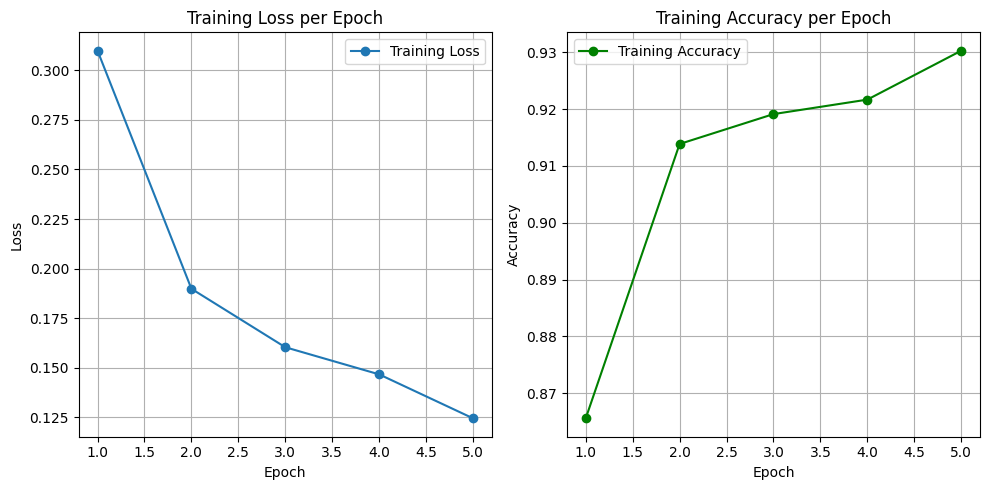

In [9]:
import time
import matplotlib.pyplot as plt

def multilabel_accuracy(y_true, y_pred, threshold=0.5):
    y_pred = (y_pred > threshold).float()
    correct = (y_pred == y_true).float()
    return correct.mean().item()

train_losses, train_accuracies = [], []

start_time = time.time()

for epoch in range(5):  # adjust epochs
    model.train()
    total_loss = 0
    total_acc = 0
    for images, modalities, labels in train_loader:
        images, modalities, labels = images.to(device), modalities.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, modalities)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += multilabel_accuracy(labels, outputs)

    avg_loss = total_loss / len(train_loader)
    avg_acc = total_acc / len(train_loader)

    train_losses.append(avg_loss)
    train_accuracies.append(avg_acc)

    print(f"Epoch [{epoch+1}/5] - Loss: {avg_loss:.4f}, Train Acc: {avg_acc:.4f}")

end_time = time.time()
elapsed_time = end_time - start_time
print(f"\n⏱️ Total training time: {elapsed_time/60:.2f} minutes")

# Plot loss and accuracy
epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'o-', label='Training Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, 'o-', color='green', label='Training Accuracy')
plt.title('Training Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [10]:
model.eval()
val_acc = 0
with torch.no_grad():
    for images, modalities, labels in val_loader:
        images, modalities, labels = images.to(device), modalities.to(device), labels.to(device)
        outputs = model(images, modalities)
        val_acc += multilabel_accuracy(labels, outputs)

val_acc /= len(val_loader)
print(f"✅ Validation Multi-label Accuracy: {val_acc:.4f}")

✅ Validation Multi-label Accuracy: 0.9300


In [11]:
# prints results in table form

import torch
import numpy as np
import pydicom
from PIL import Image
from torchvision import transforms
import os
import pandas as pd

def predict_single_image(model, image_path, device, threshold=0.5):
    """
    Predict hemorrhage class probabilities for a single CT (.dcm) or MRI (.jpg) image.
    Displays results in a horizontal table format.
    """
    model.eval()

    # --- Define image transforms (same as training) ---
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])

    # --- Detect modality and load accordingly ---
    if image_path.lower().endswith(".dcm"):
        modality_code = torch.tensor([0])  # CT = 0
        modality_str = "CT"

        dicom = pydicom.dcmread(image_path)
        image = dicom.pixel_array.astype(np.float32)
        image = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-8)
        image = np.stack([image]*3, axis=-1)
        image = Image.fromarray((image * 255).astype(np.uint8))

    else:
        modality_code = torch.tensor([1])  # MRI = 1
        modality_str = "MRI"
        image = Image.open(image_path).convert("RGB")

    image = transform(image).unsqueeze(0).to(device)
    modality_code = modality_code.to(device)

    # --- Prediction ---
    with torch.no_grad():
        output = model(image, modality_code)
        probs = output.cpu().numpy()[0]

    class_names = ['epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']
    any_prob = np.mean(probs)

    # --- Build horizontal table ---
    df = pd.DataFrame([{
        'epidural': f"{probs[0]*100:.2f}%",
        'intraparenchymal': f"{probs[1]*100:.2f}%",
        'intraventricular': f"{probs[2]*100:.2f}%",
        'subarachnoid': f"{probs[3]*100:.2f}%",
        'subdural': f"{probs[4]*100:.2f}%",
        'any (average)': f"{any_prob*100:.2f}%"
    }])

    # --- Display results ---
    print(f"\n🧠 Modality: {modality_str}")
    print(f"📂 File: {os.path.basename(image_path)}\n")
    print(df.to_markdown(index=False, tablefmt="grid"))

    if np.any(probs > threshold):
        print("\n🔴 Intracranial Hemorrhage Detected!\n")
    else:
        print("\n🟢 No Hemorrhage Detected.\n")


In [12]:
predict_single_image(model, r"..\Testing\epidural\Te-gl_0011.jpg", device)


🧠 Modality: MRI
📂 File: Te-gl_0011.jpg

+------------+--------------------+--------------------+----------------+------------+-----------------+
| epidural   | intraparenchymal   | intraventricular   | subarachnoid   | subdural   | any (average)   |
+============+====================+====================+================+============+=================+
| 99.47%     | 0.08%              | 0.01%              | 0.74%          | 0.00%      | 20.06%          |
+------------+--------------------+--------------------+----------------+------------+-----------------+

🔴 Intracranial Hemorrhage Detected!



In [13]:
predict_single_image(model, r"..\Testing\intraparenchymal\Te-me_0012.jpg", device)


🧠 Modality: MRI
📂 File: Te-me_0012.jpg

+------------+--------------------+--------------------+----------------+------------+-----------------+
| epidural   | intraparenchymal   | intraventricular   | subarachnoid   | subdural   | any (average)   |
+============+====================+====================+================+============+=================+
| 0.25%      | 43.29%             | 57.44%             | 0.17%          | 0.29%      | 20.29%          |
+------------+--------------------+--------------------+----------------+------------+-----------------+

🔴 Intracranial Hemorrhage Detected!



In [14]:
predict_single_image(model, r"..\data\stage_2_train_images\ID_0002a38ad.dcm", device)


🧠 Modality: CT
📂 File: ID_0002a38ad.dcm

+------------+--------------------+--------------------+----------------+------------+-----------------+
| epidural   | intraparenchymal   | intraventricular   | subarachnoid   | subdural   | any (average)   |
+============+====================+====================+================+============+=================+
| 0.00%      | 1.12%              | 0.42%              | 0.00%          | 0.00%      | 0.31%           |
+------------+--------------------+--------------------+----------------+------------+-----------------+

🟢 No Hemorrhage Detected.



In [15]:
predict_single_image(model, r"C:\Users\yuvar\Downloads\images.jpeg", device)


🧠 Modality: MRI
📂 File: images.jpeg

+------------+--------------------+--------------------+----------------+------------+-----------------+
| epidural   | intraparenchymal   | intraventricular   | subarachnoid   | subdural   | any (average)   |
+============+====================+====================+================+============+=================+
| 0.00%      | 0.43%              | 0.46%              | 99.87%         | 0.00%      | 20.15%          |
+------------+--------------------+--------------------+----------------+------------+-----------------+

🔴 Intracranial Hemorrhage Detected!

